# Cross-Domain Traffic Classification — Multi-Scale CNN with SPLT Features

Trains on non-VPN flows, evaluates on VPN-encapsulated flows. Input: SPLT fingerprint sequences (direction, packet size, inter-arrival time, N=50 packets). Model: parallel 1D-CNN branches (kernels 3, 7, 11) with residual connection and multi-head temporal attention. Confidence intervals from bootstrap resampling (B=1000) on the VPN test set.

In [1]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report,
                              confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print('TF version:', tf.__version__)
print('Numpy version:', np.__version__)


TF version: 2.20.0
Numpy version: 2.3.5


## Configuration

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
N          = 50          # sequence length (packets)
BATCH_SIZE = 1024
EPOCHS     = 50
SEED       = 42

# ── Data paths (relative from enhanced_v2 folder) ──────────────────────────────
VPN_FILE    = r'.\dataset\mapped_f\vpn_all_filtered_min200.csv'
NONVPN_FILE = r'.\dataset\mapped_f\nonvpn_all_filtered_min200.csv'
TARGET_COL  = 'application_category_name'

# ── Output directory ───────────────────────────────────────────────────────────
OUT_DIR = r'.\results_01_CrossDomain_CNN1D_SPLT\CNN1D'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output directory: {os.path.abspath(OUT_DIR)}')


Output directory: C:\Users\Yasameen\enhanced_v2\results_01_CrossDomain_CNN1D_SPLT\CNN1D


## Helper Functions

In [3]:
# ── Helper functions ───────────────────────────────────────────────────────────

def parse_col_fast(series, n):
    """Parse a column of SPLT sequences into a 2D numpy array.
    Handles bracket-wrapped comma-separated format like '[0, 1, -1, ...]'
    as well as plain space-separated values."""
    out = np.zeros((len(series), n), dtype=np.float32)
    for i, val in enumerate(series):
        if isinstance(val, str) and val.strip():
            s = val.strip().lstrip('[').rstrip(']')
            if ',' in s:
                s = s.replace(',', ' ')
            try:
                arr = np.fromstring(s, sep=' ', dtype=np.float32)
            except ValueError:
                continue
            ln = min(len(arr), n)
            out[i, :ln] = arr[:ln]
    return out


def build_tensor(df, dir_col, ps_col, piat_col, n, tag=''):
    """Build (N_samples, n, 3) float32 tensor from direction, packet-size and PIAT columns."""
    t0 = time.time()
    print(f'  [{tag}] parsing direction ...')
    D = parse_col_fast(df[dir_col], n)          # (S, n)
    print(f'  [{tag}] parsing packet sizes ...')
    P = parse_col_fast(df[ps_col], n)           # (S, n)
    print(f'  [{tag}] parsing PIATs ...')
    I = parse_col_fast(df[piat_col], n)         # (S, n)
    X = np.stack([D, P, I], axis=2).astype(np.float32)  # (S, n, 3)
    print(f'  [{tag}] tensor shape: {X.shape}  ({time.time()-t0:.1f}s)')
    return X


def augment_numpy(X, mask_prob=0.05, noise_std=0.02, seed=0):
    """Light augmentation: random zero-masking + small Gaussian noise."""
    rng = np.random.default_rng(seed)
    Xa = X.copy()
    mask = rng.random(Xa.shape[:2]) < mask_prob          # (S, n)
    Xa[mask] = 0.0
    Xa += rng.normal(0, noise_std, Xa.shape).astype(np.float32)
    return Xa


def compute_metrics(y_true, y_pred, proba=None, classes=None):
    """Return a dict of classification metrics."""
    metrics = {
        'accuracy':     accuracy_score(y_true, y_pred),
        'bal_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1':     f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'weighted_f1':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    return metrics


def plot_blue_cm(cm, labels, title, save_path=None):
    """Blue annotated confusion matrix using seaborn heatmap."""
    n = len(labels)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.75), max(8, n * 0.65)))
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.4, linecolor='#d0d0d0', ax=ax,
                cbar_kws={'shrink': 0.75}, annot_kws={'size': 8})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def show_metrics_table(metrics_dict, title='Metrics'):
    """Display metrics as a styled pandas DataFrame."""
    df = pd.DataFrame([metrics_dict]).round(4)
    df.index = [title]
    display(df.style.background_gradient(cmap='Blues', axis=1))
    return df


def save_results(prefix, out_dir, y_true, y_pred, proba, le):
    """Save classification report (txt), predictions (csv), metrics (json) and confusion matrix."""
    labels = list(le.classes_)
    # metrics json
    m = compute_metrics(y_true, y_pred)
    with open(os.path.join(out_dir, f'{prefix}_metrics.json'), 'w') as f:
        json.dump(m, f, indent=2)
    # classification report
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)
    with open(os.path.join(out_dir, f'{prefix}_report.txt'), 'w') as f:
        f.write(report)
    # predictions csv
    pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).to_csv(
        os.path.join(out_dir, f'{prefix}_predictions.csv'), index=False)
    # confusion matrix image
    cm = confusion_matrix(y_true, y_pred)
    cm_path = os.path.join(out_dir, f'{prefix}_confusion_matrix.png')
    plot_blue_cm(cm, labels, title=f'{prefix} — Confusion Matrix', save_path=cm_path)
    print(f'Results saved to: {out_dir}')
    return m

print('Helper functions defined.')

Helper functions defined.


## Data Loading

Loading VPN data ...
  VPN shape: (226314, 29)
Loading non-VPN data ...
  non-VPN shape: (226314, 29)

VPN class distribution:
application_category_name
Web               110690
Network            84448
Collaborative       6632
Cloud               5778
Unspecified         5680
Chat                3985
SocialNetwork       3883
VoIP                1601
System              1230
SoftwareUpdate       737
Download             651
Email                391
Database             327
ConnCheck            281
Name: count, dtype: int64

non-VPN class distribution:
application_category_name
Web               110690
Network            84448
Collaborative       6632
Cloud               5778
Unspecified         5680
Chat                3985
SocialNetwork       3883
VoIP                1601
System              1230
SoftwareUpdate       737
Download             651
Email                391
Database             327
ConnCheck            281
Name: count, dtype: int64


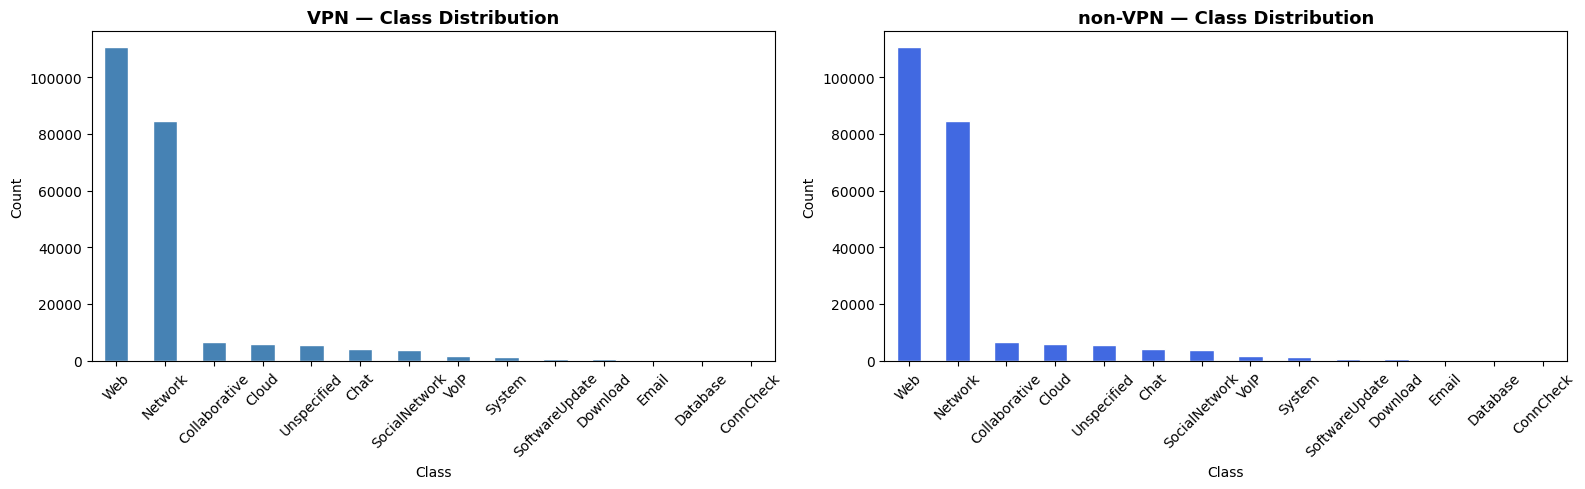

In [4]:
# ── Load data ──────────────────────────────────────────────────────────────────
print('Loading VPN data ...')
df_vpn = pd.read_csv(VPN_FILE)
print(f'  VPN shape: {df_vpn.shape}')

print('Loading non-VPN data ...')
df_nonvpn = pd.read_csv(NONVPN_FILE)
print(f'  non-VPN shape: {df_nonvpn.shape}')

print('\nVPN class distribution:')
vpn_dist = df_vpn[TARGET_COL].value_counts()
print(vpn_dist)

print('\nnon-VPN class distribution:')
nonvpn_dist = df_nonvpn[TARGET_COL].value_counts()
print(nonvpn_dist)

# Plot class distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vpn_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('VPN — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

nonvpn_dist.plot(kind='bar', ax=axes[1], color='royalblue', edgecolor='white')
axes[1].set_title('non-VPN — Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'class_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## Feature Extraction — SPLT Tensors

In [5]:
# ── Identify SPLT columns ──────────────────────────────────────────────────────
# non-VPN: inner SPLT columns
print('non-VPN columns sample:', [c for c in df_nonvpn.columns if 'pkt' in c.lower() or 'iat' in c.lower() or 'dir' in c.lower()][:10])
print('VPN columns sample:',     [c for c in df_vpn.columns    if 'pkt' in c.lower() or 'iat' in c.lower() or 'dir' in c.lower()][:10])

# ── Build tensors ──────────────────────────────────────────────────────────────
# Adjust column names below if they differ in your actual dataset
NONVPN_DIR_COL  = 'splt_direction'
NONVPN_PS_COL   = 'splt_ps'
NONVPN_PIAT_COL = 'splt_piat_ms'

VPN_DIR_COL  = 'outer_splt_direction'
VPN_PS_COL   = 'outer_splt_ps'
VPN_PIAT_COL = 'outer_splt_piat_ms'

t0 = time.time()
print('\nBuilding non-VPN tensor ...')
X_nonvpn = build_tensor(df_nonvpn, NONVPN_DIR_COL, NONVPN_PS_COL, NONVPN_PIAT_COL, N, tag='non-VPN')

print('\nBuilding VPN tensor ...')
X_vpn = build_tensor(df_vpn, VPN_DIR_COL, VPN_PS_COL, VPN_PIAT_COL, N, tag='VPN')

print(f'\nTotal tensor build time: {time.time()-t0:.1f}s')
print(f'X_nonvpn: {X_nonvpn.shape}  dtype={X_nonvpn.dtype}')
print(f'X_vpn:    {X_vpn.shape}   dtype={X_vpn.dtype}')

non-VPN columns sample: ['bidirectional_packets', 'bidirectional_bytes', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'bidirectional_duration_ms', 'bidirectional_first_seen_ms']
VPN columns sample: ['mean_outer_pkt_size', 'std_outer_pkt_size', 'outer_min_piat_ms', 'outer_mean_piat_ms', 'outer_stddev_piat_ms', 'outer_max_piat_ms', 'outer_min_piat_ms_in', 'outer_mean_piat_ms_in', 'outer_stddev_piat_ms_in', 'outer_max_piat_ms_in']

Building non-VPN tensor ...
  [non-VPN] parsing direction ...
  [non-VPN] parsing packet sizes ...
  [non-VPN] parsing PIATs ...
  [non-VPN] tensor shape: (226314, 50, 3)  (36.6s)

Building VPN tensor ...
  [VPN] parsing direction ...
  [VPN] parsing packet sizes ...
  [VPN] parsing PIATs ...
  [VPN] tensor shape: (226314, 50, 3)  (37.5s)

Total tensor build time: 74.1s
X_nonvpn: (226314, 50, 3)  dtype=float32
X_vpn:    (226314, 50, 3) 

## Label Encoding

In [6]:
# ── Label encoding ─────────────────────────────────────────────────────────────
le = LabelEncoder()

# Fit on union of both domains to ensure consistent integer mapping
all_labels = pd.concat([df_nonvpn[TARGET_COL], df_vpn[TARGET_COL]]).unique()
le.fit(all_labels)

y_nonvpn = le.transform(df_nonvpn[TARGET_COL])
y_vpn    = le.transform(df_vpn[TARGET_COL])

NUM_CLASSES = len(le.classes_)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {list(le.classes_)}')
print(f'y_nonvpn shape: {y_nonvpn.shape}')
print(f'y_vpn shape:    {y_vpn.shape}')

Number of classes: 14
Classes: ['Chat', 'Cloud', 'Collaborative', 'ConnCheck', 'Database', 'Download', 'Email', 'Network', 'SocialNetwork', 'SoftwareUpdate', 'System', 'Unspecified', 'VoIP', 'Web']
y_nonvpn shape: (226314,)
y_vpn shape:    (226314,)


## Model Architecture

In [7]:
# ── Model architecture ─────────────────────────────────────────────────────────

def sparse_focal_loss(gamma=2.0, alpha=0.25):
    """Sparse categorical focal loss for multi-class classification."""
    def focal_loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        probs  = tf.reduce_max(tf.nn.softmax(y_pred, axis=-1) *
                               tf.one_hot(y_true, tf.shape(y_pred)[-1]), axis=-1)
        ce     = tf.keras.losses.sparse_categorical_crossentropy(
                     y_true, y_pred, from_logits=False)
        focal_weight = alpha * tf.pow(1.0 - probs, gamma)
        return tf.reduce_mean(focal_weight * ce)
    focal_loss_fn.__name__ = 'sparse_focal_loss'
    return focal_loss_fn


def build_model(n, num_classes, lr=8e-4, dropout=0.4):
    """Multi-scale CNN1D with Temporal Attention and Residual connections."""
    inp = keras.Input(shape=(n, 3), name='splt_input')

    # ── Multi-scale parallel convolutions (k=3, 7, 11) ──────────────────────
    b3  = layers.Conv1D(64, 3,  padding='same', activation='relu', name='conv_k3')(inp)
    b7  = layers.Conv1D(64, 7,  padding='same', activation='relu', name='conv_k7')(inp)
    b11 = layers.Conv1D(64, 11, padding='same', activation='relu', name='conv_k11')(inp)
    x   = layers.Concatenate(name='multi_scale_concat')([b3, b7, b11])  # (n, 192)

    # ── BatchNorm ────────────────────────────────────────────────────────────
    x = layers.BatchNormalization(name='bn1')(x)

    # ── Residual block: Conv1D(192,3) + skip Conv1D(192,1) ───────────────────
    skip = layers.Conv1D(192, 1, padding='same', name='res_skip')(x)
    res  = layers.Conv1D(192, 3, padding='same', activation='relu', name='res_conv3')(x)
    res  = layers.BatchNormalization(name='bn_res')(res)
    x    = layers.Add(name='res_add')([res, skip])
    x    = layers.Activation('relu', name='res_relu')(x)

    # ── Multi-Head Attention (temporal) ──────────────────────────────────────
    attn_out = layers.MultiHeadAttention(
        num_heads=4, key_dim=48, dropout=0.1, name='mha')(x, x)
    x = layers.Add(name='attn_add')([x, attn_out])
    x = layers.LayerNormalization(name='ln1')(x)

    # ── Final conv + pooling ─────────────────────────────────────────────────
    x = layers.Conv1D(256, 3, padding='same', activation='relu', name='conv_final')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)

    # ── Dense head ───────────────────────────────────────────────────────────
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(dropout, name='drop1')(x)
    x = layers.Dense(128, activation='relu', name='fc2')(x)
    x = layers.Dropout(dropout / 2, name='drop2')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inp, out, name='MultiScale_CNN1D_Attention')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model


# Display model summary
model_summary_display = build_model(N, NUM_CLASSES)
model_summary_display.summary()
del model_summary_display

Model: "MultiScale_CNN1D_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ splt_input          │ (None, 50, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 50, 64)    │        640 │ splt_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k7 (Conv1D)    │ (None, 50, 64)    │      1,408 │ splt_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k11 (Conv1D)   │ (None, 50, 64)    │      2,176 │ splt_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_scale_concat  │ (None, 50, 192)   │          0 │ conv_k3[0][0],    │
│ (Concatenate)       │                   │            │ conv_k7[0][0],    │
│                     │                   │            │ conv_k11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 50, 192)   │        768 │ multi_scale_conc… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_conv3 (Conv1D)  │ (None, 50, 192)   │    110,784 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_res              │ (None, 50, 192)   │        768 │ res_conv3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_skip (Conv1D)   │ (None, 50, 192)   │     37,056 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_add (Add)       │ (None, 50, 192)   │          0 │ bn_res[0][0],     │
│                     │                   │            │ res_skip[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_relu            │ (None, 50, 192)   │          0 │ res_add[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 50, 192)   │    148,224 │ res_relu[0][0],   │
│ (MultiHeadAttentio… │                   │            │ res_relu[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_add (Add)      │ (None, 50, 192)   │          0 │ res_relu[0][0],   │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1                 │ (None, 50, 192)   │        384 │ attn_add[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_final (Conv1D) │ (None, 50, 256)   │    147,712 │ ln1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 50, 256)   │      1,024 │ conv_final[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ bn2[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │     65,792 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 256)       │          0 │ fc1[0][0]       

 Total params: 551,438 (2.10 MB)

 Trainable params: 550,158 (2.10 MB)

 Non-trainable params: 1,280 (5.00 KB)

## Training

In [8]:
# ── Final model: train on ALL non-VPN ─────────────────────────────────────────
print('Training final model on ALL non-VPN data ...')

# Augmentation
X_aug_final = augment_numpy(X_nonvpn, mask_prob=0.05, noise_std=0.02, seed=99)
X_final_all = np.concatenate([X_nonvpn, X_aug_final], axis=0)
y_final_all = np.concatenate([y_nonvpn, y_nonvpn],   axis=0)

# Class weights
cw_final = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_final_all)
cw_dict_final = dict(enumerate(cw_final))

tf.keras.backend.clear_session()
final_model = build_model(N, NUM_CLASSES)

callbacks_final = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = final_model.fit(
    X_final_all, y_final_all,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    class_weight=cw_dict_final,
    callbacks=callbacks_final,
    verbose=1
)

print('Final model training complete.')

Training final model on ALL non-VPN data ...

Epoch 1/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.9057 - loss: 0.0725 - val_accuracy: 0.8634 - val_loss: 0.1380 - learning_rate: 8.0000e-04
Epoch 2/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.9508 - loss: 0.0343 - val_accuracy: 0.9033 - val_loss: 0.0744 - learning_rate: 8.0000e-04
Epoch 3/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 0.9611 - loss: 0.0264 - val_accuracy: 0.8247 - val_loss: 0.1900 - learning_rate: 8.0000e-04
Epoch 4/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.9680 - loss: 0.0211 - val_accuracy: 0.9211 - val_loss: 0.0521 - learning_rate: 8.0000e-04
Epoch 5/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.9723 - loss: 0.0179 - val_accuracy: 0.9432 - val_loss: 0.0348 - learning_rate: 8.0000e-04
Epoch 6/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.9719 - loss: 0.0180 - val_accuracy: 0.7305 - val_loss: 0.1809 - learning_rate: 8.0000e-04
Epoch 7/50
3

## Evaluation on VPN Test Set

Evaluating final model on VPN test set ...
222/222 ━━━━━━━━━━━━━━━━━━━━ 58s 262ms/step

Final Model — VPN Test Set Metrics:


,accuracy,bal_accuracy,macro_f1,weighted_f1
Final Model (All non-VPN → All VPN),0.984400,0.899200,0.908900,0.983900


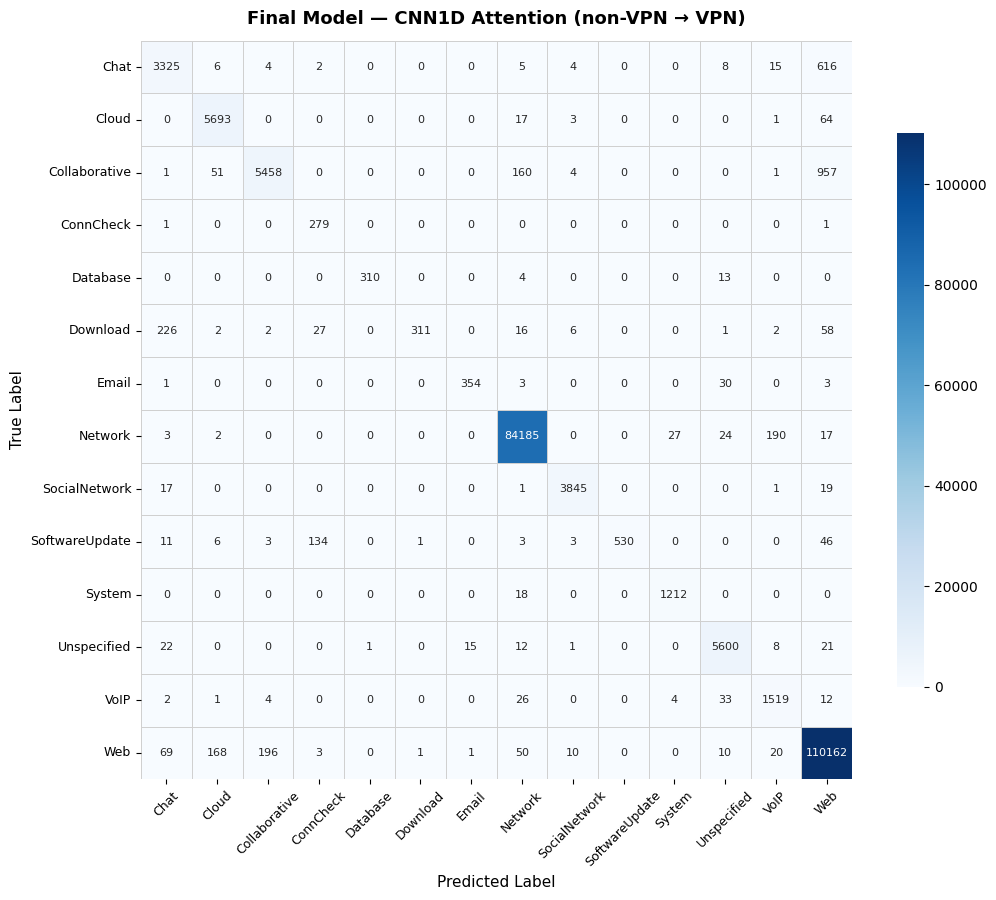

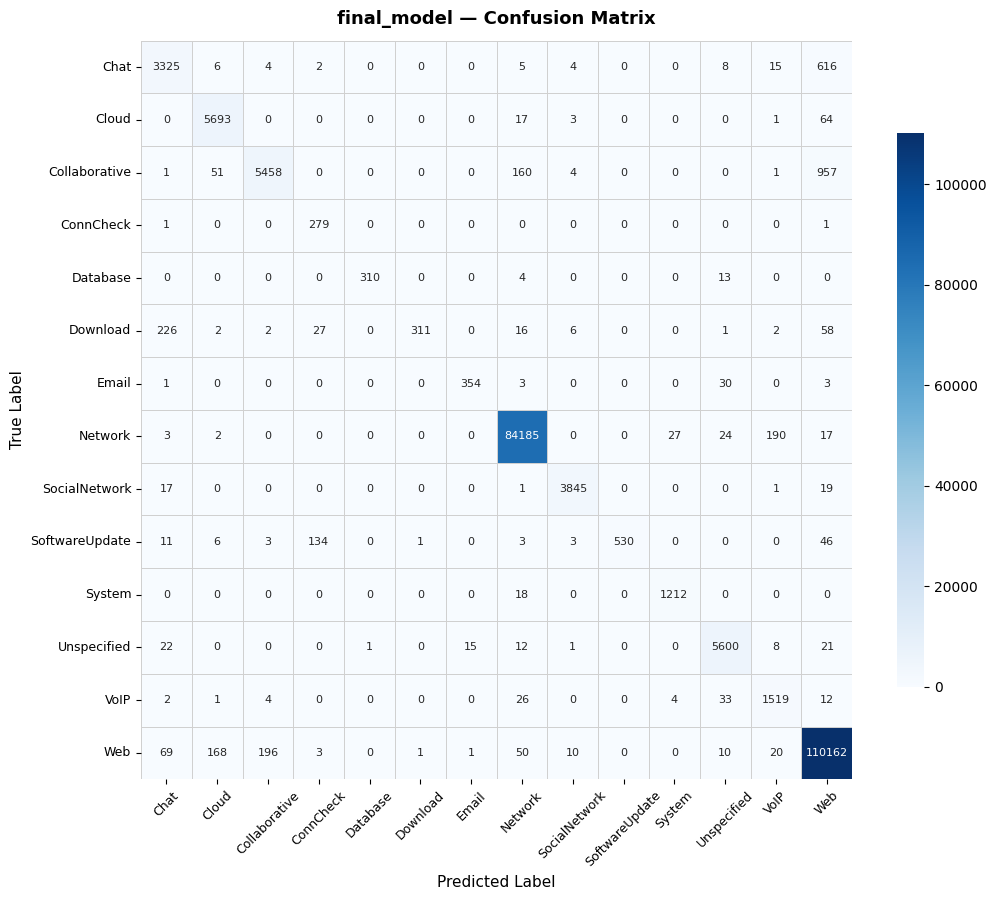

Results saved to: .\results_01_CrossDomain_CNN1D_SPLT\CNN1D
Model saved to: .\results_01_CrossDomain_CNN1D_SPLT\CNN1D\final_cnn1d_model.keras
Training history saved.


In [9]:
# ── Evaluate final model on ALL VPN ───────────────────────────────────────────
print('Evaluating final model on VPN test set ...')

proba_vpn = final_model.predict(X_vpn, batch_size=BATCH_SIZE, verbose=1)
y_pred_vpn = np.argmax(proba_vpn, axis=1)

final_metrics = compute_metrics(y_vpn, y_pred_vpn)
print('\nFinal Model — VPN Test Set Metrics:')
show_metrics_table(final_metrics, title='Final Model (All non-VPN → All VPN)')

# Blue confusion matrix
cm_final = confusion_matrix(y_vpn, y_pred_vpn)
cm_save_path = os.path.join(OUT_DIR, 'final_model_cm.png')
plot_blue_cm(cm_final, list(le.classes_),
             title='Final Model — CNN1D Attention (non-VPN → VPN)',
             save_path=cm_save_path)

# Save all results
save_results('final_model', OUT_DIR, y_vpn, y_pred_vpn, proba_vpn, le)

# Save model weights
model_save_path = os.path.join(OUT_DIR, 'final_cnn1d_model.keras')
final_model.save(model_save_path)
print(f'Model saved to: {model_save_path}')

# Save training history
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(os.path.join(OUT_DIR, 'final_model_history.csv'), index=False)
print('Training history saved.')

## Save Predictions

In [10]:
# ── Save predictions + probabilities for ROC / PR curve analysis ───────────────
# proba_vpn shape: (n_test, n_classes) — one column per class
pred_df = pd.DataFrame({
    'y_true': y_vpn,           # integer encoded true labels
    'y_pred': y_pred_vpn,      # integer encoded predicted labels
    'y_true_name': le.inverse_transform(y_vpn),
    'y_pred_name': le.inverse_transform(y_pred_vpn),
})
for j, cls in enumerate(le.classes_):
    pred_df[f'prob_{cls}'] = proba_vpn[:, j]

pred_path = os.path.join(OUT_DIR, 'cnn1d_predictions.csv')
pred_df.to_csv(pred_path, index=False)
print(f'Predictions saved: {pred_df.shape}  → {pred_path}')
print(f'Columns: y_true, y_pred, y_true_name, y_pred_name, prob_<class> x {len(le.classes_)}')

# Save class index → name mapping
import json as _json
with open(os.path.join(OUT_DIR, 'class_names.json'), 'w') as f:
    _json.dump({str(i): cls for i, cls in enumerate(le.classes_)}, f, indent=2)
print('Class name mapping saved → class_names.json')


Predictions saved: (226314, 18)  → .\results_01_CrossDomain_CNN1D_SPLT\CNN1D\cnn1d_predictions.csv
Columns: y_true, y_pred, y_true_name, y_pred_name, prob_<class> x 14
Class name mapping saved → class_names.json


## Bootstrap Confidence Intervals (B=1000)

Computing 95% Bootstrap CI (B=1000) on VPN test set...

95% Bootstrap CI — CNN1D SPLT (non-VPN → VPN):
  accuracy                 : 0.9844  95% CI [0.9839 – 0.9849]
  bal_accuracy             : 0.8992  95% CI [0.8943 – 0.9044]
  macro_f1                 : 0.9089  95% CI [0.9041 – 0.9138]
  weighted_f1              : 0.9839  95% CI [0.9833 – 0.9844]


,mean,CI_lower,CI_upper,std
metric,,,,
accuracy,0.984400,0.983900,0.984900,0.000300
bal_accuracy,0.899200,0.894300,0.904400,0.002400
macro_f1,0.908900,0.904100,0.913800,0.002500
weighted_f1,0.983900,0.983300,0.984400,0.000300


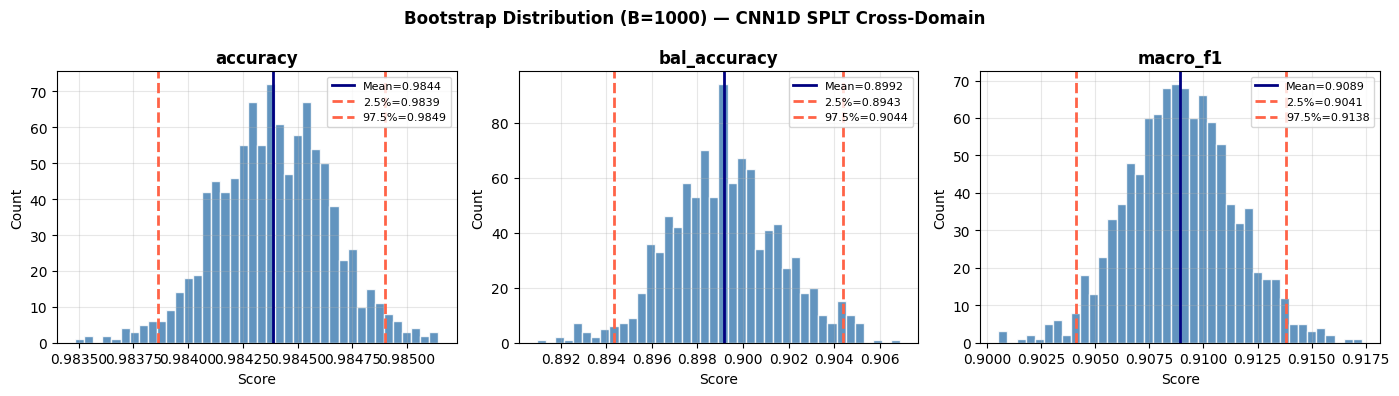

Bootstrap CI saved → .\results_01_CrossDomain_CNN1D_SPLT\CNN1D


In [11]:
# ── Bootstrap CI (B=1000) on VPN test set ─────────────────────────────────────
# Train is done once on ALL non-VPN. We resample the VPN predictions
# 1000 times to get a 95% CI on cross-domain performance.
print('Computing 95% Bootstrap CI (B=1000) on VPN test set...')
rng_boot = np.random.default_rng(SEED)
n_test   = len(y_vpn)
boot_results = []

for _ in range(1000):
    idx = rng_boot.integers(0, n_test, size=n_test)   # resample with replacement
    boot_results.append(compute_metrics(y_vpn[idx], y_pred_vpn[idx]))

# Collect CI
ci_rows = []
print('\n95% Bootstrap CI — CNN1D SPLT (non-VPN → VPN):')
for key in boot_results[0]:
    vals = [m[key] for m in boot_results]
    mean = float(np.mean(vals))
    lo   = float(np.percentile(vals, 2.5))
    hi   = float(np.percentile(vals, 97.5))
    std  = float(np.std(vals))
    print(f'  {key:25s}: {mean:.4f}  95% CI [{lo:.4f} – {hi:.4f}]')
    ci_rows.append({'metric': key, 'mean': round(mean,4),
                    'CI_lower': round(lo,4), 'CI_upper': round(hi,4), 'std': round(std,4)})

ci_df = pd.DataFrame(ci_rows).set_index('metric')
display(ci_df.style.background_gradient(cmap='Blues', axis=None))

# Distribution plot — shows how tight the CI is
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key in zip(axes, ['accuracy', 'bal_accuracy', 'macro_f1']):
    vals = [m[key] for m in boot_results]
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(vals), color='navy',   lw=2, label=f'Mean={np.mean(vals):.4f}')
    ax.axvline(lo,            color='tomato', lw=2, linestyle='--', label=f'2.5%={lo:.4f}')
    ax.axvline(hi,            color='tomato', lw=2, linestyle='--', label=f'97.5%={hi:.4f}')
    ax.set_title(key, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Bootstrap Distribution (B=1000) — CNN1D SPLT Cross-Domain', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'bootstrap_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

# Save results
ci_df.to_csv(os.path.join(OUT_DIR, 'bootstrap_ci.csv'))
with open(os.path.join(OUT_DIR, 'bootstrap_summary.json'), 'w') as f:
    json.dump({'B': 1000, 'n_test': n_test, 'results': ci_rows}, f, indent=2)
print(f'Bootstrap CI saved → {OUT_DIR}')

## Training Curves

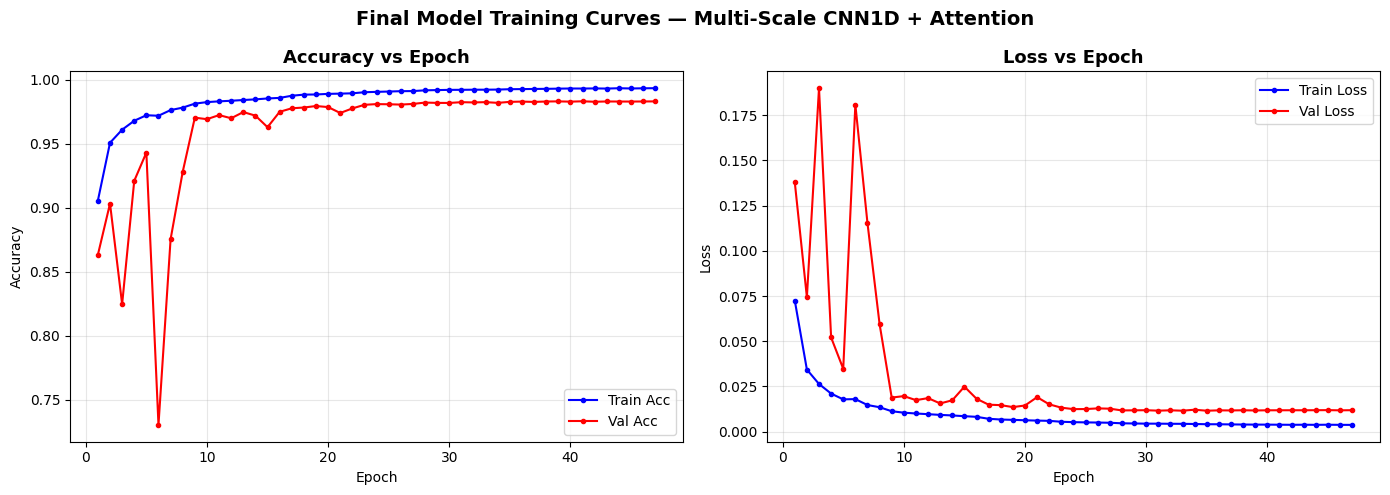

In [12]:
# ── Training curves ────────────────────────────────────────────────────────────
hist_data = history.history
epochs_ran = range(1, len(hist_data['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_ran, hist_data['accuracy'],     'b-o', markersize=3, label='Train Acc')
axes[0].plot(epochs_ran, hist_data['val_accuracy'], 'r-o', markersize=3, label='Val Acc')
axes[0].set_title('Accuracy vs Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_ran, hist_data['loss'],     'b-o', markersize=3, label='Train Loss')
axes[1].plot(epochs_ran, hist_data['val_loss'], 'r-o', markersize=3, label='Val Loss')
axes[1].set_title('Loss vs Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Final Model Training Curves — Multi-Scale CNN1D + Attention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()